In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# from hyperopt import fmin, tpe, hp, Trials, rand
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
df = pd.read_pickle(
    join(CURRENT_DIR, "..", "data", "our_data", "true_combine_cores.pkl")
)

In [3]:
df

,p450_name,complex_name,p450_score,affinity,cnn_score,cnn_affi,wei_score,dock_num,if_right,enzyme,...,ranking91,ranking92,ranking93,ranking94,ranking95,ranking96,ranking97,ranking98,ranking99,ranking100
2652,CYP706A3,CYP706A3_ABA_C14,0.185,0.011,0.625,0.385,0.405,3,True,CYP706A3,...,0.137339,0.137339,0.137339,0.141631,0.133047,0.133047,0.124464,0.128755,0.128755,0.128755
2860,CYP720B1,CYP720B1_ABI_C17,0.234,0.009,0.809,0.477,0.522,2,True,CYP720B1,...,0.012876,0.012876,0.012876,0.017167,0.017167,0.017167,0.017167,0.021459,0.021459,0.025751
3134,CYP707A1,CYP707A1_ABS_C5,0.178,0.013,0.827,0.401,0.502,3,True,CYP707A1,...,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.008584,0.008584
3454,CYP720B4,CYP720B4_ABT_C12,0.135,0.029,0.664,0.482,0.400,3,True,CYP720B4,...,0.163090,0.150215,0.141631,0.124464,0.107296,0.103004,0.103004,0.103004,0.098712,0.090129
4966,CYP51H10,CYP51H10_BAM_C15,0.174,0.020,0.595,0.511,0.384,3,True,CYP51H10,...,0.042918,0.042918,0.042918,0.042918,0.038627,0.042918,0.042918,0.042918,0.038627,0.038627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,CYP79D16,CYP79D16_PHL_C1,0.556,0.012,0.941,0.303,0.748,3,True,CYP79D16,...,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292,0.004292
57269,CYP79A2,CYP79A2_PHL_C1,0.282,0.012,0.893,0.253,0.588,3,True,CYP79A2,...,0.021459,0.021459,0.021459,0.021459,0.021459,0.021459,0.021459,0.021459,0.021459,0.021459
57270,CYP79D6,CYP79D6_PHL_C1,0.572,0.012,0.891,0.284,0.732,3,True,CYP79D6,...,0.008584,0.008584,0.008584,0.008584,0.008584,0.008584,0.008584,0.008584,0.008584,0.008584
57271,CYP79C1,CYP79C1_PHL_C1,0.501,0.013,0.883,0.254,0.692,3,True,CYP79C1,...,0.012876,0.012876,0.012876,0.012876,0.012876,0.012876,0.012876,0.012876,0.012876,0.012876


In [ ]:
dfginna = df["ranking100"]
dfesp = df["ranking0"]

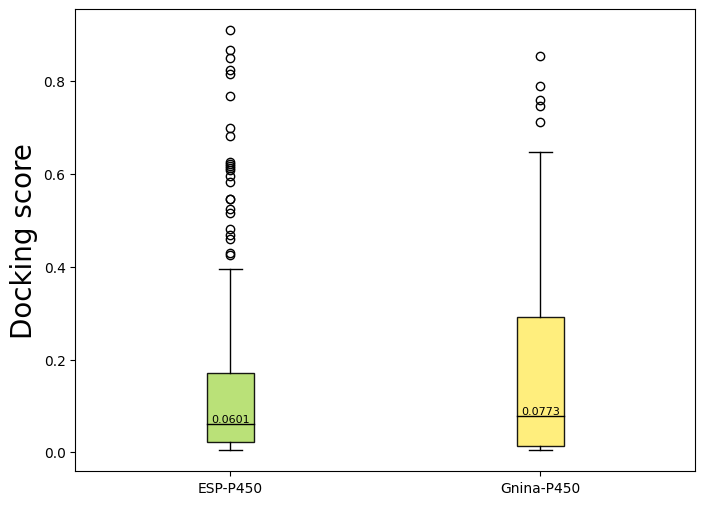

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(8, 6))
cmap = cm.Set3
box = plt.boxplot([dfesp, dfginna], patch_artist=True)

for i, patch in enumerate(box["boxes"]):
    patch.set_facecolor(cmap((i + 1) / (2)))
    patch.set_alpha(0.9)


median1 = np.median(dfesp)
median2 = np.median(dfginna)

plt.text(1, median1, f"{median1:.4f}", ha="center", va="bottom", fontsize=8)
plt.text(2, median2, f"{median2:.4f}", ha="center", va="bottom", fontsize=8)


for median in box["medians"]:
    median.set_color("black")
plt.ylabel("Docking score", fontsize=20)
plt.xticks([1, 2], ["ESP-P450", "Gnina-P450"])
plt.show()